# RDF. Сериализация RDF-графа в форматы N-Triples и Turtle.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Курс лекций [Semantic Technologies for Developers](https://yadi.sk/d/SepS4JBLhDYy4Q), лекция №01
* https://www.w3.org/TR/rdf12-n-triples/
* https://www.w3.org/TR/turtle/
* https://www.w3.org/2015/03/ShExValidata/
* https://networkx.org/documentation/stable/reference/classes/digraph.html
* https://networkx.org/documentation/stable/reference/drawing.html
* https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html

## Вопросы для совместного обсуждения

1\. Обсудите модель RDF, способы представления (сериализации) RDF-графов и проблему материализации (reification) данных.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дан фрагмент текста. Разбейте данный текст на тройки субъект-предикат-объект и сохраните в виде списка кортежей. Для каждого субъекта и нелитерального объекта введите уникальный строковый идентификатор вида `ID-{N}`. Типы отношений оформите в виде перечисления `Relation`.

Выведите на экран количество созданных троек и количество введенных идентификаторов.

Для разбиения не используйте никаких дополнительных инструментов, работайте полностью в ручном режиме. 

- [ ] Проверено на семинаре

В небольшом городке Зеленогорск живет талантливый художник Анна Петрова. Ей 35 лет, и она специализируется на пейзажной живописи. Анна создала серию картин под названием "Времена года", состоящую из четырех полотен.

Первая картина из серии, "Весеннее пробуждение", была написана в 2021 году. Она изображает цветущий яблоневый сад на фоне голубого неба. Размер холста - 80 на 60 сантиметров. Эта работа была продана на местном аукционе за 150000 рубле За рубежом данная картина известна под названием "Spring Awakening".



Анна использует в своем творчестве различные техники. Для "Весеннего пробуждения" она применила метод импасто, создавая объемные мазки масляными красками. Любимыми цветами художницы являются зеленый и синий, что отчетливо видно в ее работах.

Мастерская Анны находится на улице Лесная, дом 7. Здесь она не только работает над своими картинами, но и проводит мастер-классы для начинающих художников. Ее уроки пользуются большой популярностью, и записаться на них можно по телефону +7 (123) 456-78-90.

In [1]:
from enum import Enum, auto

In [2]:
class Relation(Enum):
    NAME = auto()
    SURNAME = auto()
    AGE = auto()
    LIVES_IN = auto()
    SPECIALIZES_IN = auto()
    CREATED = auto()
    CONSISTS_OF = auto()
    USES = auto()
    TECHNIQUE = auto()
    FAVORITE_COLOR = auto()
    ADDRESS = auto()
    PHONE = auto()
    TEACHES = auto()

In [3]:
# Создаем список кортежей (субъект, предикат, объект)
triples = [
    ("ID-1", Relation.NAME, "Анна"),
    ("ID-1", Relation.SURNAME, "Петрова"),
    ("ID-1", Relation.AGE, "35"),
    ("ID-1", Relation.LIVES_IN, "ID-2"),
    ("ID-2", Relation.NAME, "Зеленогорск"),
    ("ID-1", Relation.SPECIALIZES_IN, "пейзажная живопись"),
    ("ID-1", Relation.CREATED, "ID-3"),
    ("ID-3", Relation.NAME, "Времена года"),
    ("ID-3", Relation.CONSISTS_OF, "4"),
    ("ID-1", Relation.USES, "различные техники"),
    ("ID-4", Relation.NAME, "Весеннее пробуждение"),
    ("ID-4", Relation.TECHNIQUE, "импасто"),
    ("ID-1", Relation.FAVORITE_COLOR, "зеленый"),
    ("ID-1", Relation.FAVORITE_COLOR, "синий"),
    ("ID-5", Relation.NAME, "мастерская"),
    ("ID-5", Relation.ADDRESS, "улица Лесная, дом 7"),
    ("ID-1", Relation.TEACHES, "мастер-классы"),
    ("ID-1", Relation.PHONE, "+7 (123) 456-78-90")
]

In [4]:
# Подсчет уникальных идентификаторов
unique_ids = set()
for triple in triples:
    if triple[0].startswith('ID-'):
        unique_ids.add(triple[0])
    if isinstance(triple[2], str) and triple[2].startswith('ID-'):
        unique_ids.add(triple[2])

print(f"Количество троек: {len(triples)}")
print(f"Количество уникальных идентификаторов: {len(unique_ids)}")

Количество троек: 18
Количество уникальных идентификаторов: 5


<p class="task" id="2"></p>

2\. Используя триплеты, созданные в предыдущем задании, создайте ориентированный граф `nx.DiGraph`. На каждом ребре создайте атрибут `type`, в котором хранится значение типа отношений (`Relation`).

Визуализируйте полученный граф. Добавьте на узлы и ребра подписи. В качестве ребер подписи используйте название перечисляемого значения. Сделайте нелитеральные субъекты и объекты зелеными, а литеральные объекты - серыми.

- [ ] Проверено на семинаре

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
G = nx.DiGraph()

In [7]:
# после создание орентированного, добавляем узлы и ребра с атрибутами
for subject, predicate, obj in triples:
    G.add_node(subject, color='green' if subject.startswith('ID-') else 'gray')
    if isinstance(obj, str) and obj.startswith('ID-'):
        G.add_node(obj, color='green')
    else:
        G.add_node(obj, color='gray')
    G.add_edge(subject, obj, type=predicate.name)

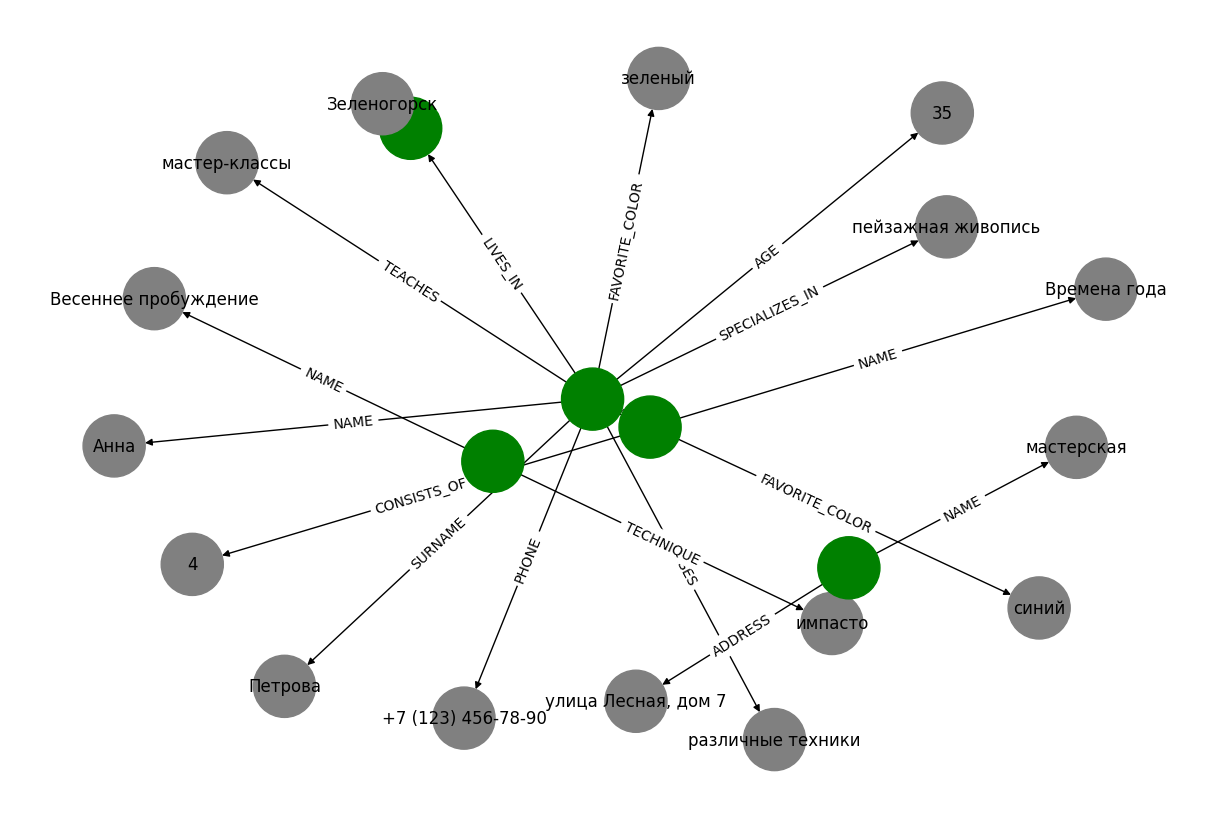

In [8]:
# Визуализация графа
pos = nx.spring_layout(G)
colors = [G.nodes[node]['color'] for node in G.nodes()]
labels = {node: node if not node.startswith('ID-') else '' for node in G.nodes()}
edge_labels = {(u, v): G.edges[u, v]['type'] for u, v in G.edges()}

plt.figure(figsize=(12, 8))
nx.draw(G, pos, node_color=colors, with_labels=True, labels=labels, node_size=2000)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

<p class="task" id="3"></p>

3\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `N-Triples`. Для формирования URI нелитеральных сущностей используйте следующие правила:

* URI для субъекта или объекта формируйте по следующему шаблону: `http://www.fa.ru/entity/{id}`, где `domain` - это домен, к которому относится сущность (человек, город и т.д.), а `id` - числовое значение идентификатора этой сущности из задания 1. Пример: `http://www.fa.ru/entity/1`.
* URI для предиката формируйте по следующему шаблону: `http://www.fa.ru/predicate/{type}`, где `type` - это название отношения в lowerCamelCase нотации. Пример: `http://www.fa.ru/predicate/livesIn`.

Литералы указывайте в двойных кавычках без дополнительных языковых тегов или типов данных.

Результат представьте в виде строки `ntriples`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

In [ ]:
def to_camel_case(s):
    return s.lower().replace('_', ' ').title().replace(' ', '')

ntriples = ""
for subject, predicate, obj in triples:
    subj_uri = f"<http://www.fa.ru/entity/{subject}>" if subject.startswith('ID-') else f'"{subject}"'
    pred_uri = f"<http://www.fa.ru/predicate/{to_camel_case(predicate.name)}>"
    obj_uri = f"<http://www.fa.ru/entity/{obj}>" if isinstance(obj, str) and obj.startswith('ID-') else f'"{obj}"'
    ntriples += f"{subj_uri} {pred_uri} {obj_uri} .\n"

print(ntriples)

<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Name> "Анна" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Surname> "Петрова" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Age> "35" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/LivesIn> <http://www.fa.ru/entity/ID-2> .
<http://www.fa.ru/entity/ID-2> <http://www.fa.ru/predicate/Name> "Зеленогорск" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/SpecializesIn> "пейзажная живопись" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Created> <http://www.fa.ru/entity/ID-3> .
<http://www.fa.ru/entity/ID-3> <http://www.fa.ru/predicate/Name> "Времена года" .
<http://www.fa.ru/entity/ID-3> <http://www.fa.ru/predicate/ConsistsOf> "4" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Uses> "различные техники" .
<http://www.fa.ru/entity/ID-4> <http://www.fa.ru/predicate/Name> "Весеннее пробуждение" .
<http://www.fa.ru/entity/ID-4> <http://www.fa.ru/predicate/

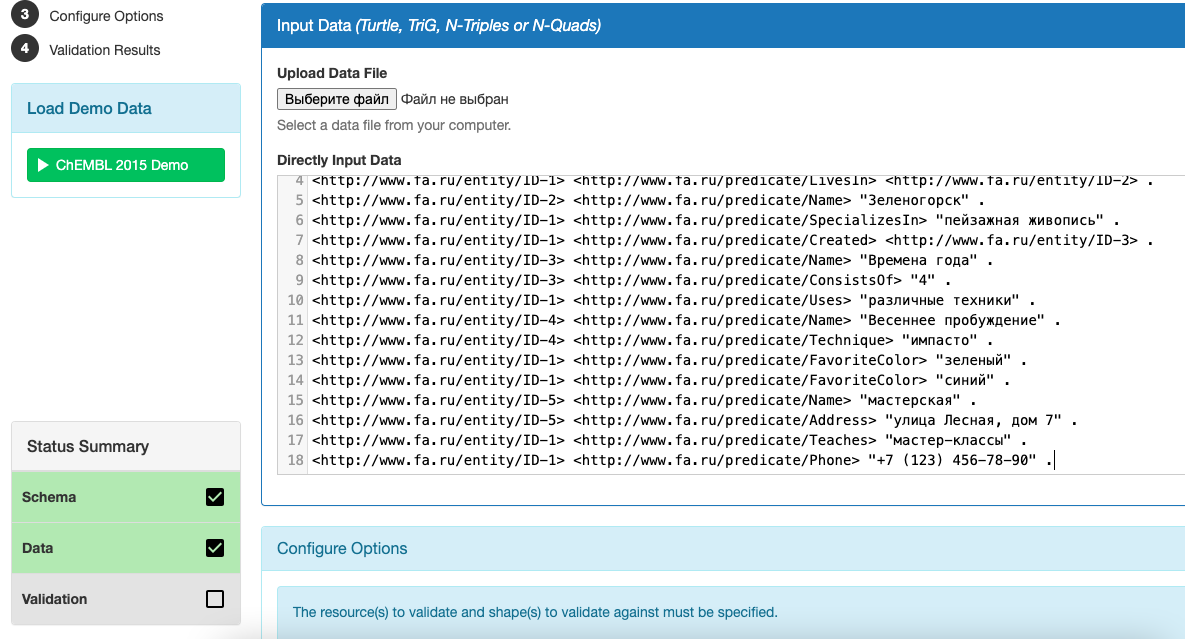

<p class="task" id="4"></p>

4\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `N-Triples`, дополнительно указав языковые теги для строковых литералов и URI типа данных для нестроковых.

Результат представьте в виде строки `ntriples_extended`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

In [10]:
ntriples_extended = ""
for subject, predicate, obj in triples:
    subj_uri = f"<http://www.fa.ru/entity/{subject}>" if subject.startswith('ID-') else f'"{subject}"'
    pred_uri = f"<http://www.fa.ru/predicate/{to_camel_case(predicate.name)}>"
    
    if isinstance(obj, str) and obj.startswith('ID-'):
        obj_uri = f"<http://www.fa.ru/entity/{obj}>"
    else:
        # Добавляем языковые теги для строковых литералов
        if predicate in [Relation.NAME, Relation.SURNAME, Relation.SPECIALIZES_IN, Relation.TECHNIQUE, Relation.FAVORITE_COLOR, Relation.ADDRESS, Relation.TEACHES]:
            obj_uri = f'"{obj}"@ru'
        elif predicate == Relation.AGE:
            obj_uri = f'"{obj}"^^<http://www.w3.org/2001/XMLSchema#integer>'
        else:
            obj_uri = f'"{obj}"'
    
    ntriples_extended += f"{subj_uri} {pred_uri} {obj_uri} .\n"

print(ntriples_extended)

<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Name> "Анна"@ru .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Surname> "Петрова"@ru .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Age> "35"^^<http://www.w3.org/2001/XMLSchema#integer> .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/LivesIn> <http://www.fa.ru/entity/ID-2> .
<http://www.fa.ru/entity/ID-2> <http://www.fa.ru/predicate/Name> "Зеленогорск"@ru .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/SpecializesIn> "пейзажная живопись"@ru .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Created> <http://www.fa.ru/entity/ID-3> .
<http://www.fa.ru/entity/ID-3> <http://www.fa.ru/predicate/Name> "Времена года"@ru .
<http://www.fa.ru/entity/ID-3> <http://www.fa.ru/predicate/ConsistsOf> "4" .
<http://www.fa.ru/entity/ID-1> <http://www.fa.ru/predicate/Uses> "различные техники" .
<http://www.fa.ru/entity/ID-4> <http://www.fa.ru/predicate/Name> "Весеннее пробуждение"@ru

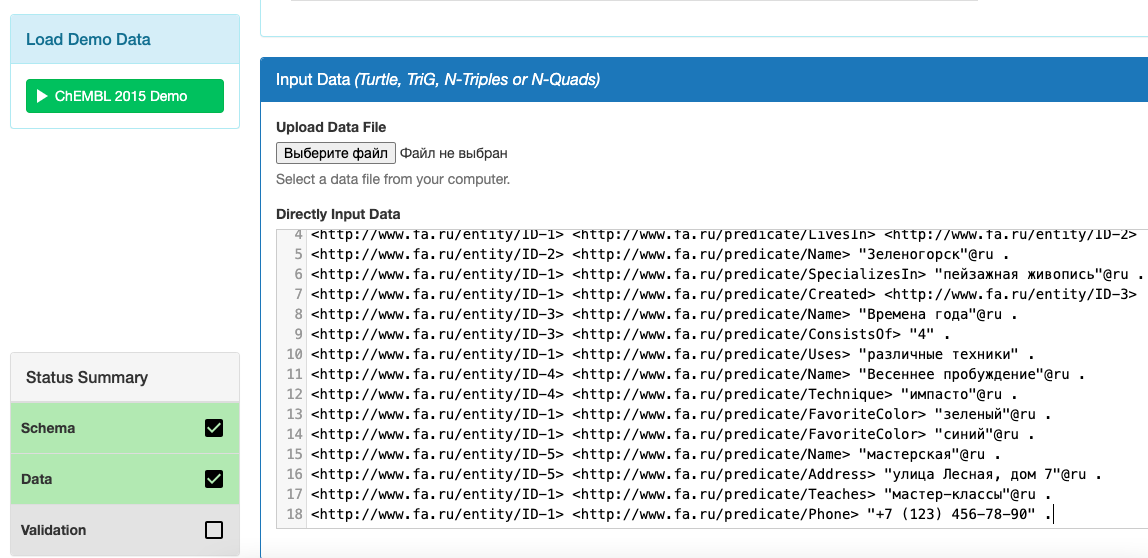

<p class="task" id="5"></p>

5\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `Turtle`. Для формирования URI нелитеральных сущностей используйте правила, аналогичные предыдущим заданиям. Используйте директиву `@prefix` для описания пространств имен для сущностей и предикатов. Для описания данных используйте только простые тройки вида субъект-предикат-объект, без списков предикатов и/или объектов.

Результат представьте в виде строки `turtle`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

In [11]:
turtle = """
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .

"""
for subject, predicate, obj in triples:
    subj_short = f"entity:{subject}" if subject.startswith('ID-') else f'"{subject}"'
    pred_short = f"predicate:{to_camel_case(predicate.name)}"
    obj_short = f"entity:{obj}" if isinstance(obj, str) and obj.startswith('ID-') else f'"{obj}"'
    turtle += f"{subj_short} {pred_short} {obj_short} .\n"

print(turtle)


@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .

entity:ID-1 predicate:Name "Анна" .
entity:ID-1 predicate:Surname "Петрова" .
entity:ID-1 predicate:Age "35" .
entity:ID-1 predicate:LivesIn entity:ID-2 .
entity:ID-2 predicate:Name "Зеленогорск" .
entity:ID-1 predicate:SpecializesIn "пейзажная живопись" .
entity:ID-1 predicate:Created entity:ID-3 .
entity:ID-3 predicate:Name "Времена года" .
entity:ID-3 predicate:ConsistsOf "4" .
entity:ID-1 predicate:Uses "различные техники" .
entity:ID-4 predicate:Name "Весеннее пробуждение" .
entity:ID-4 predicate:Technique "импасто" .
entity:ID-1 predicate:FavoriteColor "зеленый" .
entity:ID-1 predicate:FavoriteColor "синий" .
entity:ID-5 predicate:Name "мастерская" .
entity:ID-5 predicate:Address "улица Лесная, дом 7" .
entity:ID-1 predicate:Teaches "мастер-классы" .
entity:ID-1 predicate:Phone "+7 (123) 456-78-90" .



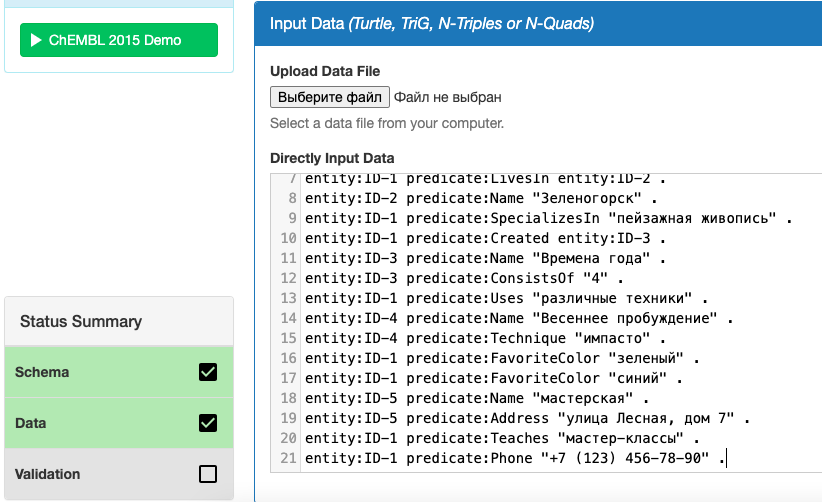

<p class="task" id="6"></p>

6\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `Turtle` с использованием списков предикатов.

Результат представьте в виде строки `turtlePredicateList`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

In [12]:
from collections import defaultdict

# Группируем предикаты по субъекту
grouped = defaultdict(list)
for subject, predicate, obj in triples:
    grouped[subject].append((predicate, obj))

turtlePredicateList = """
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .

"""
for subject, predicates in grouped.items():
    subj_short = f"entity:{subject}" if subject.startswith('ID-') else f'"{subject}"'
    turtlePredicateList += f"{subj_short}\n"
    for pred, obj in predicates:
        pred_short = f"predicate:{to_camel_case(pred.name)}"
        obj_short = f"entity:{obj}" if isinstance(obj, str) and obj.startswith('ID-') else f'"{obj}"'
        turtlePredicateList += f"    {pred_short} {obj_short} ;\n"
    turtlePredicateList = turtlePredicateList.rstrip(';\n') + " .\n\n"

print(turtlePredicateList)


@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .

entity:ID-1
    predicate:Name "Анна" ;
    predicate:Surname "Петрова" ;
    predicate:Age "35" ;
    predicate:LivesIn entity:ID-2 ;
    predicate:SpecializesIn "пейзажная живопись" ;
    predicate:Created entity:ID-3 ;
    predicate:Uses "различные техники" ;
    predicate:FavoriteColor "зеленый" ;
    predicate:FavoriteColor "синий" ;
    predicate:Teaches "мастер-классы" ;
    predicate:Phone "+7 (123) 456-78-90"  .

entity:ID-2
    predicate:Name "Зеленогорск"  .

entity:ID-3
    predicate:Name "Времена года" ;
    predicate:ConsistsOf "4"  .

entity:ID-4
    predicate:Name "Весеннее пробуждение" ;
    predicate:Technique "импасто"  .

entity:ID-5
    predicate:Name "мастерская" ;
    predicate:Address "улица Лесная, дом 7"  .




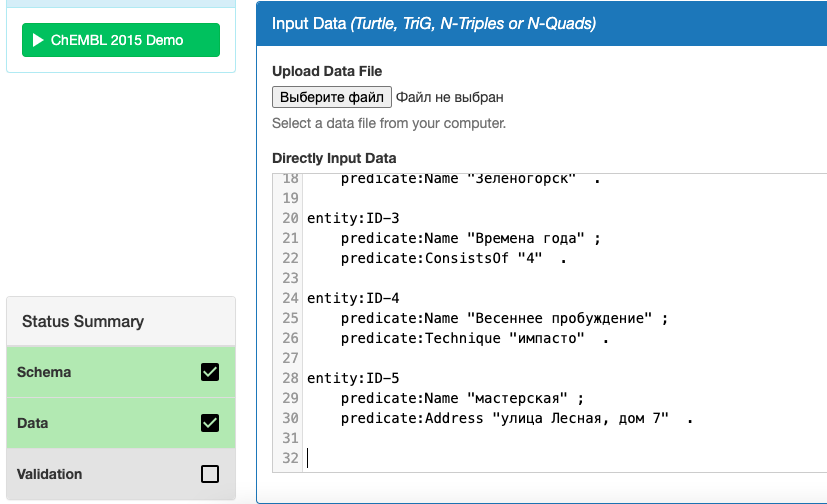

На странице [История языка программирования Python](https://en.wikipedia.org/wiki/History_of_Python) содержится информация о релизах основных и промежуточных версий. Требуется представить эту информацию в виде RDF-графа, где субъектом выступает сущность Python, а объектами - номера версий. Проблема заключается в том, что дополнительно к каждой тройке требуется прикрепить дополнительную информацию о датах начала и окончания поддержки конкретного релиза (т.н. квалификаторы) - т.е. решить задачу материализации (reification).

<p class="task" id="7"></p>

7\. Соберите данные о датах релиза и окончания поддержки для всех основных версий Python в виде словаря. Выведите на экран количество ключей данного словаря. Для получения информации из таблицы на странице можно воспользоваться [pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_html.html).

Выполните процедуру материализации по следующей схеме (__схема 1__) и сериализуйте полученных RDF-граф в формате `Turtle`. При сериализации используйте префиксы, указанные ниже. Для узлов с префиксом `statement` вы должны сгенерировать уникальный идентификатор. Можете сделать это любым удобным способом, например, воспользоваться [uuid](https://docs.python.org/3/library/uuid.html). Результат представьте в виде строки `pythonVersionsV1`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

```turtle
@prefix hasSubject: <http://www.fa.ru/hasSubject/> .
@prefix hasPredicate: <http://www.fa.ru/hasPredicate/> . 
@prefix hasObject: <http://www.fa.ru/hasObject/> .
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .
@prefix statement: <http://www.fa.ru/statement/> .

```

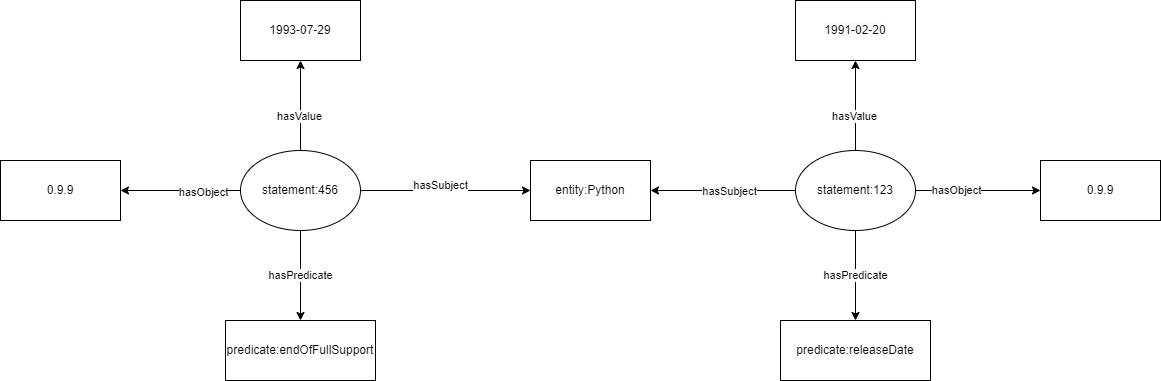

In [19]:
pip install lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 1.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd
from typing import TypedDict
import re
import requests
import uuid

In [21]:
from typing import TypedDict

class Qualifiers(TypedDict):
    release_date: str
    end_of_full_support: str

python_versions: dict[str, Qualifiers] = {}

In [22]:
url = 'https://en.wikipedia.org/wiki/History_of_Python'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

/var/folders/l6/hgcfppld1r9b94p4h4m34fgh0000gn/T/ipykernel_3958/2904164439.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [23]:
version_history_table = None
for table in tables:
    if 'Version' in table.columns and 'Release date' in table.columns:
        version_history_table = table
        break

In [24]:
def clean_cell(cell_data):
    return re.split(r'\[\d+\]', str(cell_data))[0].strip()

In [25]:
if version_history_table is not None:
    for index, row in version_history_table.iterrows():
        version = clean_cell(row['Version'])
        
        if version.count('.') == 1:
            release_date = clean_cell(row['Release date'])
            end_support = clean_cell(row['End of full support'])
            
            python_versions[version] = {
                'release_date': release_date,
                'end_of_full_support': end_support
            }

print(f"Количество ключей в словаре: {len(python_versions)}")


Количество ключей в словаре: 31


In [26]:
prefixes = """@prefix hasSubject: <http://www.fa.ru/hasSubject/> .
@prefix hasPredicate: <http://www.fa.ru/hasPredicate/> .
@prefix hasObject: <http://www.fa.ru/hasObject/> .
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .
@prefix statement: <http://www.fa.ru/statement/> .
"""

In [27]:
turtle_lines = [prefixes]
main_subject = "entity:Python"

In [28]:
for version, qualifiers in python_versions.items():
    statement_id = uuid.uuid4()
    statement_uri = f"statement:{statement_id}"

    turtle_lines.append(f"{statement_uri} hasSubject: {main_subject} .")
    turtle_lines.append(f"{statement_uri} hasPredicate: predicate:majorVersion .")
    turtle_lines.append(f'{statement_uri} hasObject: "{version}" .')
    
    turtle_lines.append(f'{statement_uri} predicate:releaseDate "{qualifiers["release_date"]}" .')
    turtle_lines.append(f'{statement_uri} predicate:endOfFullSupport "{qualifiers["end_of_full_support"]}" .')
    turtle_lines.append("")

In [29]:
pythonVersionsV1 = "\n".join(turtle_lines)
print(pythonVersionsV1)

@prefix hasSubject: <http://www.fa.ru/hasSubject/> .
@prefix hasPredicate: <http://www.fa.ru/hasPredicate/> .
@prefix hasObject: <http://www.fa.ru/hasObject/> .
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .
@prefix statement: <http://www.fa.ru/statement/> .

statement:66b25671-c9ce-4a49-bb83-4270a33b6303 hasSubject: entity:Python .
statement:66b25671-c9ce-4a49-bb83-4270a33b6303 hasPredicate: predicate:majorVersion .
statement:66b25671-c9ce-4a49-bb83-4270a33b6303 hasObject: "0.9" .
statement:66b25671-c9ce-4a49-bb83-4270a33b6303 predicate:releaseDate "1991-02-20" .
statement:66b25671-c9ce-4a49-bb83-4270a33b6303 predicate:endOfFullSupport "1993-07-29[a]" .

statement:256023eb-70af-4421-9e1e-6e5e1c9ac69e hasSubject: entity:Python .
statement:256023eb-70af-4421-9e1e-6e5e1c9ac69e hasPredicate: predicate:majorVersion .
statement:256023eb-70af-4421-9e1e-6e5e1c9ac69e hasObject: "1.0" .
statement:256023eb-70af-4421-9e1e-6e5e1c9ac69e predicate:rel

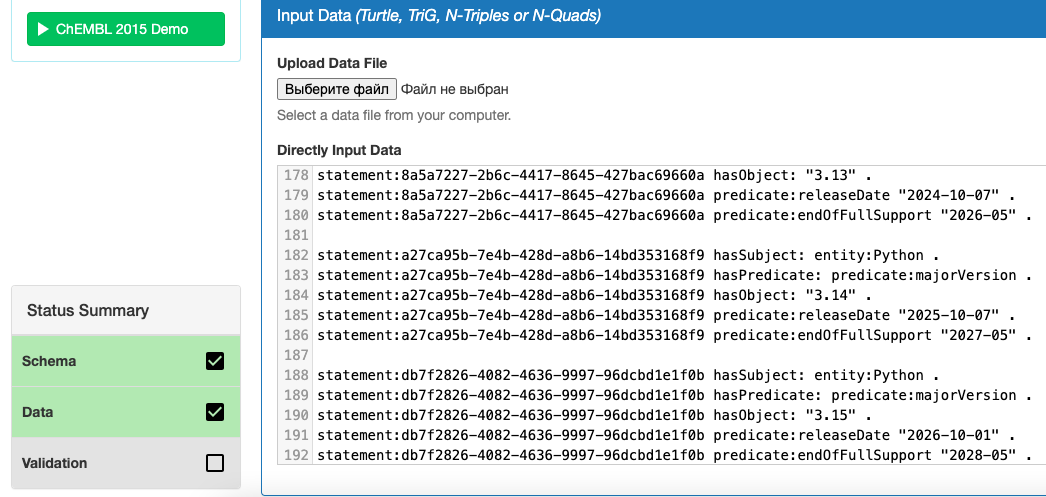

<p class="task" id="8"></p>

8\. Выполните процедуру материализации по следующей схеме (__схема 2__) и сериализуйте полученных RDF-граф в формате `Turtle`. Результат представьте в виде строки `pythonVersionsV2`. Выведите полученную строку на экран. 

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

```turtle
@prefix e: <http://www.fa.ru/entity/> .
@prefix p: <http://www.fa.ru/prop/> .
@prefix pq: <http://www.fa.ru/prop/qualifier/> .
@prefix ps: <http://www.fa.ru/prop/statement/> .
@prefix s: <http://www.wikidata.org/entity/statement/> .

`````

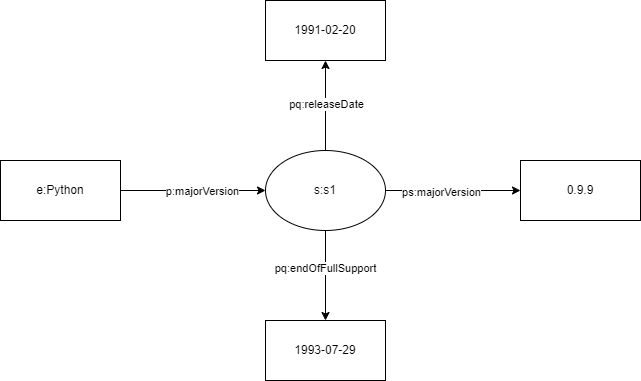

In [30]:
class Qualifiers(TypedDict):
    release_date: str
    end_of_full_support: str

python_versions: dict[str, Qualifiers] = {}

url = 'https://en.wikipedia.org/wiki/History_of_Python'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

In [31]:
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

version_history_table = None
for table in tables:
    if 'Version' in table.columns and 'Release date' in table.columns:
        version_history_table = table
        break

/var/folders/l6/hgcfppld1r9b94p4h4m34fgh0000gn/T/ipykernel_3958/821255973.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [32]:
def clean_cell(cell_data):
    return re.split(r'\[\d+\]', str(cell_data))[0].strip()

if version_history_table is not None:
    for index, row in version_history_table.iterrows():
        version = clean_cell(row['Version'])
        
        if version.count('.') == 1:
            release_date = clean_cell(row['Release date'])
            end_support = clean_cell(row['End of full support'])
            
            python_versions[version] = {
                'release_date': release_date,
                'end_of_full_support': end_support
            }

In [33]:
prefixes = """@prefix e: <http://www.fa.ru/entity/> .
@prefix p: <http://www.fa.ru/prop/> .
@prefix pq: <http://www.fa.ru/prop/qualifier/> .
@prefix ps: <http://www.fa.ru/prop/statement/> .
@prefix s: <http://www.wikidata.org/entity/statement/> .
"""

In [34]:
turtle_lines = [prefixes]

main_subject = "e:Python"
main_predicate = "p:majorVersion"
statement_predicate = "ps:majorVersion"
release_date_qualifier = "pq:releaseDate"
end_support_qualifier = "pq:endOfFullSupport"

In [35]:
for version, qualifiers in python_versions.items():
    statement_id = uuid.uuid4()
    statement_uri = f"s:{statement_id}"

    turtle_lines.append(f"{main_subject} {main_predicate} {statement_uri} .")
    
    statement_block = [
        f'    {statement_predicate} "{version}"',
        f'    {release_date_qualifier} "{qualifiers["release_date"]}"',
        f'    {end_support_qualifier} "{qualifiers["end_of_full_support"]}"'
    ]
    
    turtle_lines.append(f"{statement_uri}\n" + " ;\n".join(statement_block) + " .")
    turtle_lines.append("")

In [36]:
pythonVersionsV2 = "\n".join(turtle_lines)
print(pythonVersionsV2)

@prefix e: <http://www.fa.ru/entity/> .
@prefix p: <http://www.fa.ru/prop/> .
@prefix pq: <http://www.fa.ru/prop/qualifier/> .
@prefix ps: <http://www.fa.ru/prop/statement/> .
@prefix s: <http://www.wikidata.org/entity/statement/> .

e:Python p:majorVersion s:a1a878f4-5eb4-4171-999e-2d0400d65273 .
s:a1a878f4-5eb4-4171-999e-2d0400d65273
    ps:majorVersion "0.9" ;
    pq:releaseDate "1991-02-20" ;
    pq:endOfFullSupport "1993-07-29[a]" .

e:Python p:majorVersion s:e1242223-125a-4043-bf18-08f97ec2e75d .
s:e1242223-125a-4043-bf18-08f97ec2e75d
    ps:majorVersion "1.0" ;
    pq:releaseDate "1994-01-26" ;
    pq:endOfFullSupport "1994-07-14[a]" .

e:Python p:majorVersion s:5cec3229-8a13-4c73-bfef-01a933100999 .
s:5cec3229-8a13-4c73-bfef-01a933100999
    ps:majorVersion "1.1" ;
    pq:releaseDate "1994-10-11" ;
    pq:endOfFullSupport "1994-11-10[a]" .

e:Python p:majorVersion s:9c33d2ce-4909-429a-964e-a9e2b1b60704 .
s:9c33d2ce-4909-429a-964e-a9e2b1b60704
    ps:majorVersion "1.2" ;
    pq:

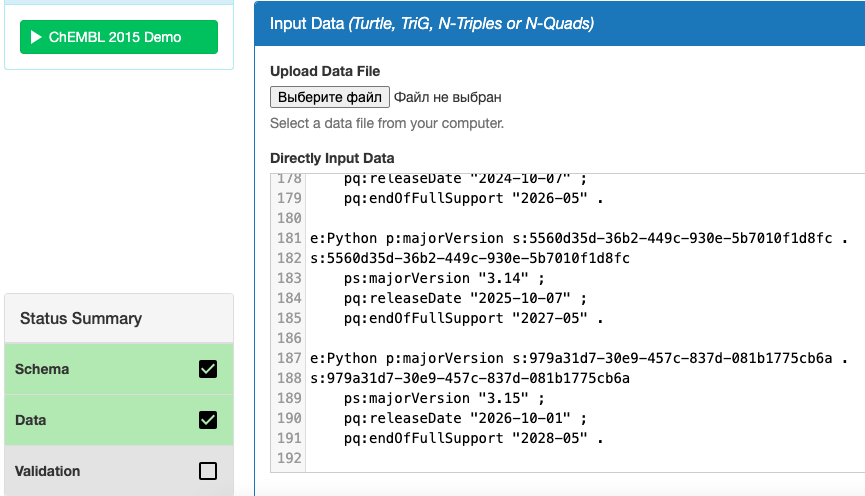